# *******Rezvan *******

# Libraries

In [3]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import os


# Data Path and Loading

In [4]:
DATA_DIR = Path("../data/eye_tracking")

csv_files = sorted(DATA_DIR.glob("*.csv"))
print(csv_files[:3])

file_path = csv_files[1]  # Christian on-boarding

df = pd.read_csv(file_path, low_memory=False)

# extract participant_id from filename
participant_id = file_path.name[:2]
df["participant_id"] = participant_id

print(df.shape)

[WindowsPath('../data/eye_tracking/01_ET_Data_2026-02-19.csv'), WindowsPath('../data/eye_tracking/02_ET_Data_2026-03-10.csv')]
(384510, 61)


# Estimate Sampling Rate

In [5]:
t = pd.to_numeric(df["gaze_capture_time"], errors="coerce")
dt_ns = t.diff().dropna()

median_dt_ns = dt_ns.median()
sampling_rate_hz = 1e9 / median_dt_ns

print(f"Estimated sampling rate: {sampling_rate_hz:.2f} Hz")
print(f"Median sample interval: {median_dt_ns:.0f} ns")
print(f"Median sample interval: {median_dt_ns / 1e6:.3f} ms")

Estimated sampling rate: 199.98 Hz
Median sample interval: 5000600 ns
Median sample interval: 5.001 ms


In [6]:
def add_time_per_model(df, time_col: str = "gaze_capture_time"):
    """
    Add time_ms per model_name, respecting experiment order.

    Sorting:
    condition_number → trial_number → time

    Assumes:
    - time_col is in nanoseconds
    - df contains: model_name, condition_number, trial_number
    """

    df = df.copy()

    # correct ordering of experiment
    df = df.sort_values(["condition_number", "trial_number", time_col])

    # compute relative time per model
    t0 = df.groupby("model_name")[time_col].transform("first")

    df["time_ms"] = (df[time_col] - t0) / 1_000_000.0

    return df

df = add_time_per_model(df, time_col="gaze_capture_time")

seg = (
    df[(df["condition_number"] == 1) &
             (df["trial_number"] == 1)]
    .sort_values("time_ms")
    .reset_index(drop=True)
)

seg["dt_ms"] = seg["time_ms"].diff()
print(seg.loc[545:555, ["time_ms", "dt_ms", "left_status", "right_status", "frame_number"]].to_string())

         time_ms       dt_ms  left_status right_status  frame_number
545  2726.339200    5.003008  Compensated  Compensated        585037
546  2731.339392    5.000192      Tracked  Compensated        585038
547  2736.339712    5.000320      Tracked  Compensated        585039
548  2741.343744    5.004032      Tracked  Compensated        585040
549  2746.345088    5.001344      Tracked  Compensated        585041
550  2751.346560    5.001472      Tracked  Compensated        585042
551  2761.345792    9.999232      Tracked      Invalid        585044
552  2966.369664  205.023872  Compensated      Invalid        585085
553  3006.374016   40.004352      Invalid      Visible        585093
554  3171.398784  165.024768      Visible      Invalid        585126
555  3176.401664    5.002880      Visible      Invalid        585127


# Preprocessing Function

In [7]:
def cleaning_function(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess eye-tracking data for analysis.

    Steps:

       - remove training models (TM) and NaN
 ......
    """

    df = df.copy()

    mask = (
        df["model_name"].notna() &
        (~df["model_name"].str.contains("TM", na=False))
    )
    df = df.loc[mask].copy()


    return df

df_clean = cleaning_function(df)
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.000000
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.000192
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.997184
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.997888
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.999616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.389248
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.387520
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.386944
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.386368


# Time Function

In [8]:
def add_time_per_model(df, time_col: str = "gaze_capture_time"):
    """
    Add time_ms per model_name, respecting experiment order.

    Sorting:
    condition_number → trial_number → time

    Assumes:
    - time_col is in nanoseconds
    - df contains: model_name, condition_number, trial_number
    """

    df = df.copy()

    # correct ordering of experiment
    df = df.sort_values(["condition_number", "trial_number", time_col])

    # compute relative time per model
    t0 = df.groupby("model_name")[time_col].transform("first")

    df["time_ms"] = (df[time_col] - t0) / 1_000_000.0

    return df

df_clean = add_time_per_model(df_clean, time_col="gaze_capture_time")
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.3892
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.3875
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.3869
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.3863


# Computing angular velocity in original vectors

In [9]:
def add_angular_velocity_before(df, time_col="gaze_capture_time"):
    df = df.copy()
    df = df.sort_values(["condition_number", "trial_number", time_col])
    df["angular_velocity_before"] = np.nan

    for (_, _), sub in df.groupby(["condition_number", "trial_number"], sort=False):
        idx = sub.index

        g = sub[[
            "gaze_forward_x",
            "gaze_forward_y",
            "gaze_forward_z"
        ]].to_numpy(dtype=float)

        norms = np.linalg.norm(g, axis=1, keepdims=True)
        g = g / np.clip(norms, 1e-12, None)

        g_prev = g[:-1]
        g_curr = g[1:]

        cross_norm = np.linalg.norm(np.cross(g_prev, g_curr), axis=1)
        dot_prod = np.sum(g_prev * g_curr, axis=1)
        angles_rad = np.arctan2(cross_norm, dot_prod)

        t = sub[time_col].to_numpy(dtype=np.int64)
        dt = np.diff(t) * 1e-9

        vel = np.full(len(sub), np.nan)
        valid = dt > 0
        vel[1:][valid] = np.degrees(angles_rad[valid] / dt[valid])

        df.loc[idx, "angular_velocity_before"] = vel

    return df


In [10]:

df_clean = add_angular_velocity_before(df_clean, time_col="gaze_capture_time")


# Define Valid Samples and Interpolation

In [11]:
FORWARD_COLS = ["gaze_forward_x", "gaze_forward_y", "gaze_forward_z"]
CLEAN_FORWARD_COLS = ["clean_gaze_forward_x", "clean_gaze_forward_y", "clean_gaze_forward_z"]


def good_status(left_status: pd.Series, right_status: pd.Series) -> np.ndarray:
    l = left_status.astype(str).str.lower().str.strip()
    r = right_status.astype(str).str.lower().str.strip()

    allowed_pairs = {
        ("tracked", "tracked"),
        ("tracked", "compensated"),
        ("compensated", "tracked"),
        ("compensated", "compensated")
    }

    good = pd.Series(
        [(ls, rs) in allowed_pairs for ls, rs in zip(l, r)],
        index=left_status.index
    )

    return good.to_numpy(dtype=bool)

def find_runs(mask: np.ndarray):
    mask = np.asarray(mask, dtype=bool)
    idx = np.flatnonzero(mask)

    if len(idx) == 0:
        return []

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k

    runs.append((start, prev))
    return runs

def expand_runs(runs, n, pad=2):
    """
    Expand each run by `pad` samples on both sides,
    then merge overlaps.
    """
    if len(runs) == 0:
        return []

    expanded = []
    for a, b in runs:
        aa = max(0, a - pad)
        bb = min(n - 1, b + pad)
        expanded.append((aa, bb))

    expanded.sort()
    merged = [expanded[0]]

    for a, b in expanded[1:]:
        prev_a, prev_b = merged[-1]
        if a <= prev_b + 1:
            merged[-1] = (prev_a, max(prev_b, b))
        else:
            merged.append((a, b))

    return merged


def normalize_xyz(xyz: np.ndarray) -> np.ndarray:
    xyz = np.asarray(xyz, dtype=float)
    nrm = np.linalg.norm(xyz, axis=1)
    out = np.full_like(xyz, np.nan, dtype=float)
    good = np.isfinite(nrm) & (nrm > 1e-8) & np.all(np.isfinite(xyz), axis=1)
    out[good] = xyz[good] / nrm[good, None]
    return out


def interpolate_segment(sub: pd.DataFrame, forward_cols=FORWARD_COLS, pad: int = 2) -> pd.DataFrame:
    sub = sub.sort_values("time_ms").copy()
    t = sub["time_ms"].to_numpy(dtype=float)

    xyz = np.column_stack([
        pd.to_numeric(sub[c], errors="coerce").to_numpy(dtype=float)
        for c in forward_cols
    ])

    good = good_status(sub["left_status"], sub["right_status"])
    bad = ~good
    bad_runs = find_runs(bad)

    n = len(sub)
    is_interpolated = np.zeros(n, dtype=bool)

    clean = xyz.copy()

    # expand bad runs by buffer
    buffered_runs = expand_runs(bad_runs, n=n, pad=pad)

    # set buffered regions to NaN before interpolation
    for a, b in buffered_runs:
        clean[a:b+1, :] = np.nan

    for a, b in buffered_runs:
        left = a - 1
        right = b + 1

        bracketed = (
            left >= 0 and
            right < n and
            np.all(np.isfinite(xyz[left])) and
            np.all(np.isfinite(xyz[right]))
        )

        if bracketed:
            for dim in range(3):
                clean[a:b+1, dim] = np.interp(
                    t[a:b+1],
                    [t[left], t[right]],
                    [xyz[left, dim], xyz[right, dim]]
                )

            clean[a:b+1, :] = normalize_xyz(clean[a:b+1, :])
            is_interpolated[a:b+1] = True

    sub["good_sample"] = good
    sub["bad_sample"] = bad
    sub["is_interpolated"] = is_interpolated

    for j, c in enumerate(forward_cols):
        sub[f"clean_{c}"] = clean[:, j]

    return sub


def interpolate_all_segments(df: pd.DataFrame, pad: int = 2) -> pd.DataFrame:
    out = []

    for (cond, trial), sub in df.groupby(["condition_number", "trial_number"], sort=True):
        cleaned = interpolate_segment(sub, forward_cols=FORWARD_COLS, pad=pad)
        cleaned["segment_label"] = f"C{int(cond)}_T{int(trial)}"
        out.append(cleaned)

    return (
        pd.concat(out, axis=0)
        .sort_values(["condition_number", "trial_number", "time_ms"])
        .reset_index(drop=True)
    )



In [12]:
df_clean = interpolate_all_segments(df_clean)


# Smoothing the data: 5-median filter

In [13]:
def median_filter_valid_runs(x: pd.Series, window: int = 5) -> pd.Series:
    y = x.to_numpy(dtype=float).copy()
    out = y.copy()

    valid = np.isfinite(y)
    idx = np.flatnonzero(valid)

    if len(idx) == 0:
        return pd.Series(out, index=x.index)

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k
    runs.append((start, prev))

    for a, b in runs:
        seg = pd.Series(y[a:b+1])

        # centered 5-point median, allowing shorter windows at edges
        filt = seg.rolling(window=window, center=True, min_periods=1).median()

        out[a:b+1] = filt.to_numpy()

    return pd.Series(out, index=x.index)

WINDOW = 5

for col in CLEAN_FORWARD_COLS:
    df_clean[col] = (
        df_clean.groupby(["condition_number", "trial_number"])[col]
        .transform(lambda x: median_filter_valid_runs(x, window=WINDOW))
    )

# renormalize after median filtering
xyz = df_clean[CLEAN_FORWARD_COLS].to_numpy(dtype=float)
df_clean[CLEAN_FORWARD_COLS] = normalize_xyz(xyz)


# Sorting

In [14]:
df_clean = df_clean.sort_values(["condition_number", "trial_number", "gaze_capture_time"])
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms
0,1000325398422099900,1773140944969,41.12195,2.000000,525251,0.293504,Valid,0.012164,-0.266522,0.963752,...,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02,NaN
1,1000325398427100300,1773140944973,41.12195,2.000000,525252,0.315788,Valid,0.013124,-0.265512,0.964018,...,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02,NaN
2,1000325398432112600,1773140944973,41.12195,2.000000,525253,0.354264,Valid,0.014052,-0.264599,0.964256,...,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02,NaN
3,1000325398437113000,1773140944973,41.12195,2.000000,525254,0.441358,Valid,0.014769,-0.263616,0.964515,...,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02,NaN
4,1000325398442101200,1773140944973,41.12195,2.000000,525255,0.473352,Valid,0.015610,-0.262661,0.964762,...,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384505,1000328184386556900,1773143730444,1607.74300,1.276645,1082229,1.000000,Valid,-0.036495,0.168651,0.985000,...,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,NaN
384506,1000328184391558700,1773143730454,1607.75400,1.277654,1082230,0.998679,Valid,-0.036406,0.169091,0.984928,...,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,NaN
384507,1000328184396558500,1773143730454,1607.75400,1.278499,1082231,0.993781,Valid,-0.036322,0.169536,0.984854,...,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,NaN
384508,1000328184401558700,1773143730465,1607.76500,1.277999,1082232,0.982768,Valid,-0.036273,0.170024,0.984772,...,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,NaN


In [15]:
pd.set_option("display.max_columns", None)

df_clean.head()

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,gaze_origin_x,gaze_origin_y,gaze_origin_z,left_forward_x,left_forward_y,left_forward_z,left_origin_x,left_origin_y,left_origin_z,left_status,left_pupil_diameter,left_iris_diameter,left_pupil_iris_ratio,left_eye_openness,right_forward_x,right_forward_y,right_forward_z,right_origin_x,right_origin_y,right_origin_z,right_status,right_pupil_diameter,right_iris_diameter,right_pupil_iris_ratio,right_eye_openness,inter_pupillary_distance,hmd_position_x,hmd_position_y,hmd_position_z,hmd_rotation_x,hmd_rotation_y,hmd_rotation_z,hmd_rotation_w,model_name,is_building_model,hit_obj_name,calibration_state,calibration_attempts,left_eye_calibration_quality,right_eye_calibration_quality,condition_number,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms,angular_velocity_before,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,0,0,0,0.047548,0.143904,0.988449,-0.033577,0,0,Tracked,4.820606,12.65099,0.381046,1.0,-0.021272,0.144035,0.989344,0.033577,0,0,Tracked,5.292973,12.58795,0.420479,0.973268,67.2,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000,NaN,True,False,False,0.013078,0.144172,0.989466,C1_T1
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,0,0,0,0.047397,0.144022,0.988439,-0.033577,0,0,Tracked,4.815219,12.65099,0.380620,1.0,-0.021240,0.144152,0.989328,0.033577,0,0,Tracked,5.293125,12.58795,0.420491,0.973297,67.2,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002,1.420650,True,False,False,0.013059,0.144225,0.989459,C1_T1
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,0,0,0,0.047250,0.144130,0.988430,-0.033577,0,0,Tracked,4.812161,12.65099,0.380378,1.0,-0.021218,0.144258,0.989313,0.033577,0,0,Tracked,5.294265,12.58795,0.420582,0.973327,67.2,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972,1.307756,True,False,False,0.013039,0.144279,0.989451,C1_T1
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,0,0,0,0.047095,0.144188,0.988429,-0.033577,0,0,Tracked,4.808924,12.65099,0.380122,1.0,-0.021184,0.144316,0.989305,0.033577,0,0,Tracked,5.295160,12.58795,0.420653,0.973373,67.2,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980,0.791661,True,False,False,0.013003,0.144336,0.989443,C1_T1
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,0,0,0,0.046948,0.144232,0.988429,-0.033577,0,0,Tracked,4.806955,12.65099,0.379967,1.0,-0.021160,0.144359,0.989299,0.033577,0,0,Tracked,5.296308,12.58795,0.420744,0.973384,67.2,0.352550,1.598016,0.020432,0.079370,0.704137,-0.074286,0.701693,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997,0.664515,True,False,False,0.012964,0.144336,0.989444,C1_T1


# Interpolation Check

In [16]:
def plot_interpolation_xyz(
    df_segment: pd.DataFrame,
    center_start: int,
    center_end: int,
    pad: int = 20
):
    """
    Plot raw vs cleaned x/y/z around one interpolated run.
    """
    sub = df_segment.sort_values("time_ms").reset_index(drop=True)

    a = max(0, center_start - pad)
    b = min(len(sub) - 1, center_end + pad)
    win = sub.iloc[a:b+1].copy()

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    for ax, comp in zip(axes, ["x", "y", "z"]):
        raw_col = f"gaze_forward_{comp}"
        clean_col = f"clean_gaze_forward_{comp}"

        ax.plot(win["time_ms"], win[raw_col], label=f"raw {comp}")
        ax.plot(win["time_ms"], win[clean_col], label=f"clean {comp}")

        interp_mask = win["is_interpolated"].fillna(False).to_numpy(dtype=bool)
        if interp_mask.any():
            interp_times = win.loc[interp_mask, "time_ms"]
            ax.axvspan(interp_times.min(), interp_times.max(), alpha=0.2)

        ax.set_ylabel(comp)
        ax.legend()

    cond = win["condition_number"].iloc[0]
    trial = win["trial_number"].iloc[0]
    axes[0].set_title(f"Condition {cond}, Trial {trial}")
    axes[-1].set_xlabel("time_ms")

    plt.tight_layout()
    plt.show()

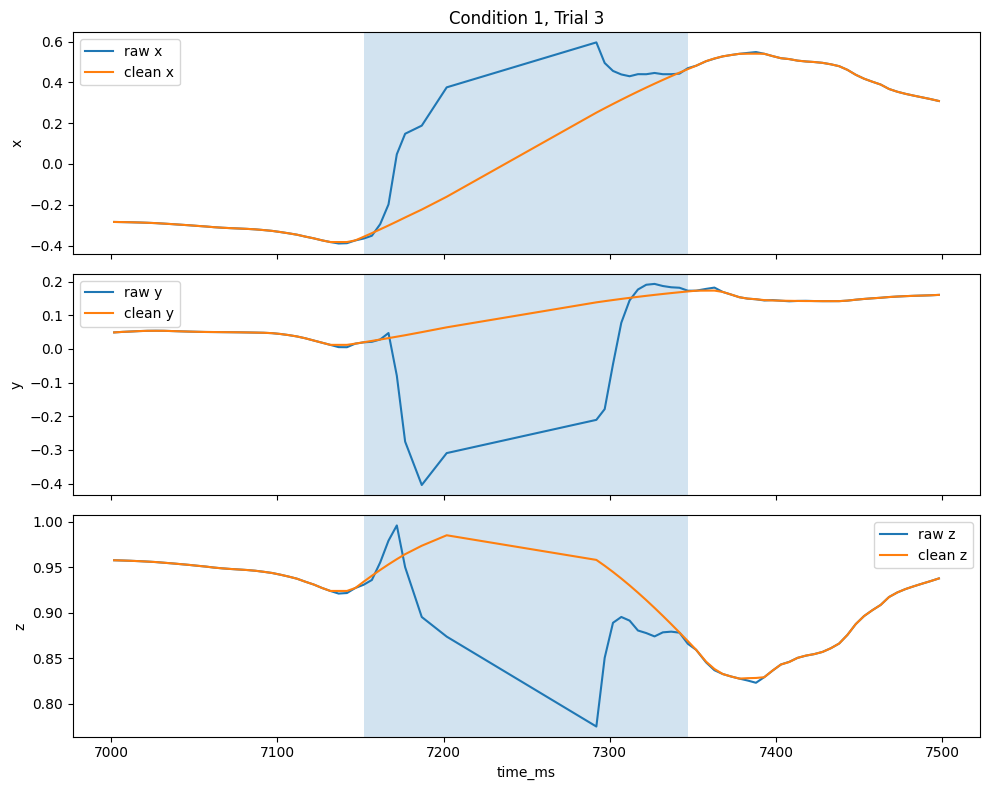

In [17]:
seg = (
    df_clean[(df_clean["condition_number"] == 1) &
             (df_clean["trial_number"] == 3)]
    .sort_values("time_ms")
    .reset_index(drop=True)
)

runs = find_runs(seg["is_interpolated"].fillna(False).to_numpy())
if runs:
    a, b = runs[0]
    plot_interpolation_xyz(seg, a, b, pad=30)



# Angular Velocity

In [18]:
def add_angular_velocity(df, time_col="gaze_capture_time"):
    """
    Compute gaze angular velocity (deg/s) from Varjo gaze_forward vectors.

    Method
    ------
    1. Take consecutive 3D gaze direction vectors.
    2. Compute the angle between them with:
           angle = atan2(||g_prev x g_curr||, g_prev · g_curr)
       This is numerically stable.
    3. Divide by the time difference in seconds.
    4. Convert from rad/s to deg/s.

    Assumptions
    -----------
    - gaze_forward_x/y/z describe gaze direction.
    - time_col is in nanoseconds.
    - Velocity should be computed within each participant/model block.

    Returns
    -------
    df : copy of input dataframe with a new column:
         - angular_velocity
    """
    df = df.copy()

    # Sort so consecutive rows are truly consecutive in time
    df = df.sort_values(
        ["condition_number", "trial_number", time_col]
    )

    # Initialize output column
    df["angular_velocity"] = np.nan

    # Compute separately within each continuous block
    for (_, _), sub in df.groupby(["condition_number", "trial_number"], sort=False):
        idx = sub.index

        # Extract gaze direction vectors
        g = sub[[
            "clean_gaze_forward_x",
            "clean_gaze_forward_y",
            "clean_gaze_forward_z"
        ]].to_numpy(dtype=float)

        # Normalize vectors just in case they are not perfectly unit length
        norms = np.linalg.norm(g, axis=1, keepdims=True)
        g = g / np.clip(norms, 1e-12, None)

        # Previous and current vectors
        g_prev = g[:-1]
        g_curr = g[1:]

        # Angle between consecutive vectors:
        # angle = atan2(||cross||, dot)
        cross_norm = np.linalg.norm(np.cross(g_prev, g_curr), axis=1)
        dot_prod = np.sum(g_prev * g_curr, axis=1)
        angles_rad = np.arctan2(cross_norm, dot_prod)

        # Time difference in seconds (timestamps are in nanoseconds)
        t = sub[time_col].to_numpy(dtype=np.int64)
        dt = np.diff(t) * 1e-9

        # Prepare output for this block
        vel = np.full(len(sub), np.nan)

        # Only compute where dt is valid
        valid = dt > 0
        vel[1:][valid] = np.degrees(angles_rad[valid] / dt[valid])

        # Write back into dataframe
        df.loc[idx, "angular_velocity"] = vel

    return df

In [19]:
df_clean = add_angular_velocity(df_clean, time_col="gaze_capture_time")

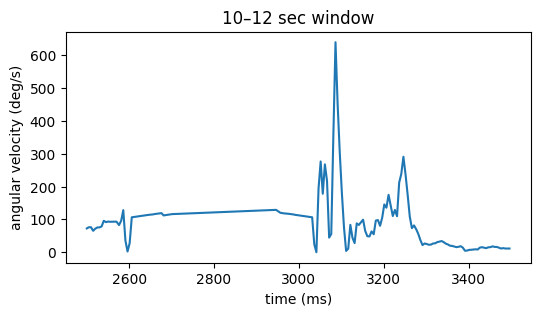

In [20]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 2500) &   # 10 sec
    (df_clean["time_ms"] <= 3500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

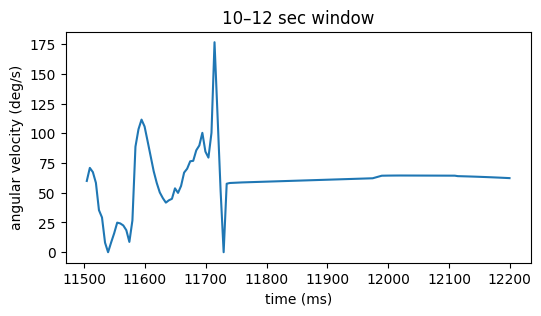

In [21]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 1) &
    (df_clean["time_ms"] >= 11500) &   # 10 sec
    (df_clean["time_ms"] <= 12200)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

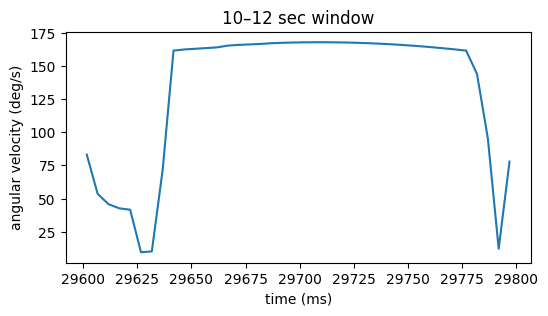

In [22]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 4) &
    (df_clean["time_ms"] >= 29600) &   # 10 sec
    (df_clean["time_ms"] <= 29800)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

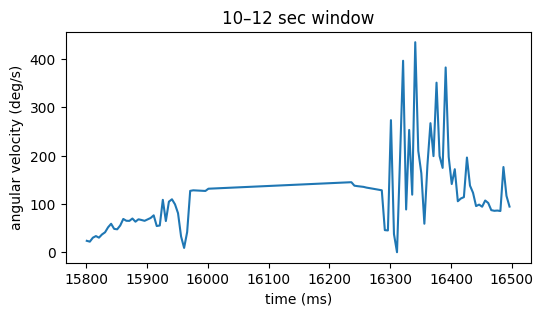

In [23]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 4) &
    (df_clean["time_ms"] >= 15800) &   # 10 sec
    (df_clean["time_ms"] <= 16500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

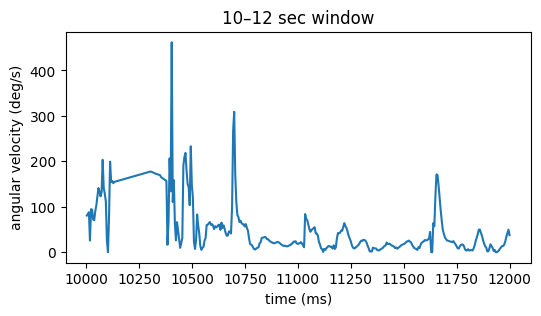

In [24]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 10000) &   # 10 sec
    (df_clean["time_ms"] <= 12000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

# Descriptive Statistics

## Percentage of Interpolation

In [25]:
n_total = len(df_clean)
n_interp = df_clean["is_interpolated"].sum()

pct_interp = 100 * n_interp / n_total

print("\n=== Interpolation stats (FULL dataset) ===")
print(f"Total samples: {n_total}")
print(f"Interpolated samples: {n_interp}")
print(f"Percentage interpolated: {pct_interp:.2f}%")


=== Interpolation stats (FULL dataset) ===
Total samples: 202969
Interpolated samples: 7126
Percentage interpolated: 3.51%


## number of rows with high velocity

In [26]:
THRESHOLD = 800
high_vel = df_clean[df_clean["angular_velocity"] > THRESHOLD]

n_spikes = len(high_vel)
n_total = len(df_clean)

pct = 100 * n_spikes / n_total

print("=== Spike samples ===")
print(f"Total samples: {n_total}")
print(f"Spike samples (> {THRESHOLD}): {n_spikes}")
print(f"Percentage: {pct:.2f}%")

=== Spike samples ===
Total samples: 202969
Spike samples (> 800): 28
Percentage: 0.01%


## Interpolated Segments Durations

In [27]:
# make sure rows are in time order
df_clean = df_clean.sort_values(
    ["condition_number", "trial_number", "gaze_capture_time"]
).copy()

def find_true_runs(x):
    runs = []
    start = None

    for i, val in enumerate(x):
        if val and start is None:
            start = i
        elif not val and start is not None:
            runs.append((start, i - 1))
            start = None

    if start is not None:
        runs.append((start, len(x) - 1))

    return runs

segment_rows = []

for (cond, trial), sub in df_clean.groupby(["condition_number", "trial_number"]):
    sub = sub.reset_index(drop=True)

    runs = find_true_runs(sub["is_interpolated"].to_numpy())

    for start, end in runs:
        n_samples = end - start + 1

        start_time = sub.loc[start, "gaze_capture_time"]
        end_time = sub.loc[end, "gaze_capture_time"]

        # duration in ms
        duration_ms = (end_time - start_time) / 1e6

        segment_rows.append({
            "condition_number": cond,
            "trial_number": trial,
            "start_idx": start,
            "end_idx": end,
            "n_samples": n_samples,
            "start_time": start_time,
            "end_time": end_time,
            "duration_ms": duration_ms
        })

interp_segments = pd.DataFrame(segment_rows)

print("=== Interpolated segments ===")
print(f"Number of interpolated segments: {len(interp_segments)}")

print("\n=== Segment length in samples ===")
print(interp_segments["n_samples"].describe())

print("\n=== Segment duration in ms ===")
print(interp_segments["duration_ms"].describe())

=== Interpolated segments ===
Number of interpolated segments: 319

=== Segment length in samples ===
count    319.000000
mean      22.338558
std       29.041254
min        7.000000
25%        7.000000
50%       16.000000
75%       25.000000
max      281.000000
Name: n_samples, dtype: float64

=== Segment duration in ms ===
count     319.000000
mean      203.919445
std       217.358361
min        29.992600
25%        30.007800
50%       155.019500
75%       285.537150
max      1640.209300
Name: duration_ms, dtype: float64


In [28]:
runs = find_runs(seg["is_interpolated"].fillna(False).to_numpy())

print("Number of runs:", len(runs))

for a, b in runs[:5]:
    print(
        (seg["gaze_capture_time"].iloc[b] - seg["gaze_capture_time"].iloc[a]) / 1e6
    )

Number of runs: 17
195.021
470.0591
30.0056
150.0167
135.0279


## Checking the sampling rate after interpolation

In [29]:
df_clean["dt"] = df_clean.groupby(
    ["condition_number", "trial_number"]
)["time_ms"].diff()

In [30]:
df_clean["dt"].describe()

count    202951.000000
mean          5.156031
std           5.418010
min           3.964800
25%           4.999800
50%           5.000600
75%           5.001400
max         485.055300
Name: dt, dtype: float64

In [31]:
### Checking whether before or after 

# Comparing high velocity before and after interpolation

In [32]:
tmp = (
    df_clean
    .sort_values(["condition_number", "trial_number", "gaze_capture_time"])
    .assign(
        dt_ms=lambda d: d.groupby(
            ["condition_number", "trial_number"]
        )["gaze_capture_time"].diff() / 1e6,
        sampling_rate_hz=lambda d: 1000 / d["dt_ms"]
    )
)

In [33]:
high_vel_after = tmp[tmp["angular_velocity"] > 800]
low_sr_after = high_vel_after[high_vel_after["sampling_rate_hz"] < 199]

n_high = len(high_vel_after)
n_low_sr = len(low_sr_after)
pct_low_sr = 100 * n_low_sr / n_high if n_high > 0 else np.nan

print("\n=== High velocity AFTER interpolation ===")
print(f"Count > 800: {n_high}")

print("\n=== Low sampling rate among those ===")
print(f"Count < 199 Hz: {n_low_sr}")
print(f"Percentage: {pct_low_sr:.2f}%")


=== High velocity AFTER interpolation ===
Count > 800: 28

=== Low sampling rate among those ===
Count < 199 Hz: 0
Percentage: 0.00%


In [34]:
high_vel_before = tmp[tmp["angular_velocity_before"] > 800]
low_sr_before = high_vel_before[high_vel_before["sampling_rate_hz"] < 199]

n_high_b = len(high_vel_before)
n_low_sr_b = len(low_sr_before)
pct_low_sr_b = 100 * n_low_sr_b / n_high_b if n_high_b > 0 else np.nan

print("\n=== High velocity BEFORE interpolation ===")
print(f"Count > 800: {n_high_b}")

print("\n=== Low sampling rate among those ===")
print(f"Count < 199 Hz: {n_low_sr_b}")
print(f"Percentage: {pct_low_sr_b:.2f}%")


=== High velocity BEFORE interpolation ===
Count > 800: 1052

=== Low sampling rate among those ===
Count < 199 Hz: 147
Percentage: 13.97%


In [35]:
# direct comparison
print("\n=== COMPARISON ===")
print(f"High velocity count: BEFORE={n_high_b} | AFTER={n_high}")
print(f"Low SR %:           BEFORE={pct_low_sr_b:.2f}% | AFTER={pct_low_sr:.2f}%")


=== COMPARISON ===
High velocity count: BEFORE=1052 | AFTER=28
Low SR %:           BEFORE=13.97% | AFTER=0.00%


In [36]:
vel_col = "angular_velocity"   # or "angular_velocity_before"

tmp = (
    df_clean
    .sort_values(["condition_number", "trial_number", "gaze_capture_time"])
    .copy()
)

tmp["dt_ms"] = (
    tmp.groupby(["condition_number", "trial_number"])["gaze_capture_time"]
    .diff() / 1e6
)

tmp["sampling_rate_hz"] = np.where(
    tmp["dt_ms"] > 0,
    1000 / tmp["dt_ms"],
    np.nan
)

tmp["high_vel"] = tmp[vel_col] > 800

tmp["prev_high"] = (
    tmp.groupby(["condition_number", "trial_number"])["high_vel"]
    .shift(1)
    .astype("boolean")
    .fillna(False)
)

tmp["next_high"] = (
    tmp.groupby(["condition_number", "trial_number"])["high_vel"]
    .shift(-1)
    .astype("boolean")
    .fillna(False)
)

tmp["isolated_high"] = (
    tmp["high_vel"] &
    (~tmp["prev_high"]) &
    (~tmp["next_high"])
)

tmp["prev_interp"] = (
    tmp.groupby(["condition_number", "trial_number"])["is_interpolated"]
    .shift(1)
    .astype("boolean")
    .fillna(False)
)

tmp["next_interp"] = (
    tmp.groupby(["condition_number", "trial_number"])["is_interpolated"]
    .shift(-1)
    .astype("boolean")
    .fillna(False)
)

tmp["near_interpolation"] = (
    tmp["is_interpolated"] |
    tmp["prev_interp"] |
    tmp["next_interp"]
)

isolated = tmp[tmp["isolated_high"]].copy()

print(f"\nVelocity column used: {vel_col}")
print(f"Total isolated spikes: {len(isolated)}")

print("\n=== Isolated spikes near interpolation ===")
print(isolated["near_interpolation"].value_counts(dropna=False))
print(isolated["near_interpolation"].value_counts(normalize=True, dropna=False) * 100)

isolated["before_interp"] = isolated["next_interp"]
isolated["after_interp"] = isolated["prev_interp"]

print("\n=== Before interpolation ===")
print(isolated["before_interp"].sum())

print("\n=== After interpolation ===")
print(isolated["after_interp"].sum())

print("\n=== Example isolated spikes ===")
print(isolated[[
    "gaze_capture_time",
    vel_col,
    "dt_ms",
    "sampling_rate_hz",
    "is_interpolated",
    "prev_interp",
    "next_interp",
    "left_status",
    "right_status"
]].head(20).to_string(index=False))


Velocity column used: angular_velocity
Total isolated spikes: 14

=== Isolated spikes near interpolation ===
near_interpolation
False    13
True      1
Name: count, dtype: Int64
near_interpolation
False    92.857143
True      7.142857
Name: proportion, dtype: Float64

=== Before interpolation ===
1

=== After interpolation ===
0

=== Example isolated spikes ===
  gaze_capture_time  angular_velocity    dt_ms  sampling_rate_hz  is_interpolated  prev_interp  next_interp left_status right_status
1000325972713909200        923.980969 5.000576        199.976963            False        False        False Compensated  Compensated
1000326013790115300        803.911553 5.000576        199.976963            False        False        False     Tracked      Tracked
1000326103174451400        843.379597 5.000576        199.976963            False        False        False Compensated  Compensated
1000327013114889300        838.628899 5.007872        199.685615            False        False        F

## Plots of Spikes before and after preprocessing

In [43]:
def plot_spike_before_after(
    df_trial: pd.DataFrame,
    center_idx: int,
    pad: int = 20,
    before_col: str = "angular_velocity_before",
    after_col: str = "angular_velocity",
):
    """
    Plot angular velocity before vs after interpolation around one spike.
    """
    sub = (
        df_trial
        .sort_values("gaze_capture_time")
        .reset_index(drop=True)
        .copy()
    )

    # normalize time so trial starts at 0 ms
    sub["time_ms"] = (
        sub["gaze_capture_time"] - sub["gaze_capture_time"].iloc[0]
    ) / 1e6

    a = max(0, center_idx - pad)
    b = min(len(sub) - 1, center_idx + pad)
    win = sub.iloc[a:b+1].copy().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(win["time_ms"], win[before_col], label="before interpolation")
    ax.plot(win["time_ms"], win[after_col], label="after interpolation")

    # mark each interpolated run separately
    interp_mask = win["is_interpolated"].fillna(False).to_numpy(dtype=bool)
    runs = find_runs(interp_mask)

    first_span = True
    for r0, r1 in runs:
        t0 = win["time_ms"].iloc[r0]
        t1 = win["time_ms"].iloc[r1]
        if first_span:
            ax.axvspan(t0, t1, alpha=0.2, label="interpolated region")
            first_span = False
        else:
            ax.axvspan(t0, t1, alpha=0.2)

    # mark chosen spike center
    spike_t = sub.loc[center_idx, "time_ms"]
    ax.axvline(spike_t, linestyle="--", alpha=0.7, label="spike center")

    cond = sub["condition_number"].iloc[0]
    trial = sub["trial_number"].iloc[0]

    ax.set_title(f"Condition {cond}, Trial {trial}, center idx {center_idx}")
    ax.set_xlabel("time (ms)")
    ax.set_ylabel("angular velocity (deg/s)")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [44]:
# find spike centers from different trials
def get_spike_examples_from_different_trials(
    df: pd.DataFrame,
    mode: str = "after",          # "after", "before", or "changed"
    threshold: float = 800,
    delta_threshold: float = 300,
    max_plots: int = 10,
):
    """
    Return up to max_plots spike examples from different trials.

    mode="after"   -> choose rows where angular_velocity > threshold
    mode="before"  -> choose rows where angular_velocity_before > threshold
    mode="changed" -> choose rows where abs(after - before) > delta_threshold
    """
    tmp = (
        df.sort_values(["condition_number", "trial_number", "gaze_capture_time"])
          .reset_index(drop=False)   # keep original index just in case
          .copy()
    )

    if mode == "after":
        cand = tmp[tmp["angular_velocity"] > threshold].copy()
        cand["score"] = cand["angular_velocity"]
    elif mode == "before":
        cand = tmp[tmp["angular_velocity_before"] > threshold].copy()
        cand["score"] = cand["angular_velocity_before"]
    elif mode == "changed":
        cand = tmp.copy() 
        cand["delta_abs"] = (
            cand["angular_velocity"] - cand["angular_velocity_before"]
        ).abs()
        cand = cand[cand["delta_abs"] > delta_threshold].copy()
        cand["score"] = cand["delta_abs"]
    else:
        raise ValueError("mode must be 'after', 'before', or 'changed'")

    # biggest spikes first
    cand = cand.sort_values("score", ascending=False)

    chosen = []
    used_trials = set()

    for _, row in cand.iterrows():
        key = (row["condition_number"], row["trial_number"])
        if key in used_trials:
            continue

        # get row position within its trial after sorting
        trial_df = (
            df[
                (df["condition_number"] == row["condition_number"]) &
                (df["trial_number"] == row["trial_number"])
            ]
            .sort_values("gaze_capture_time")
            .reset_index(drop=True)
        )

        # find matching row inside that trial by timestamp
        matches = np.where(trial_df["gaze_capture_time"].to_numpy() == row["gaze_capture_time"])[0]
        if len(matches) == 0:
            continue

        center_idx = int(matches[0])

        chosen.append({
            "condition_number": row["condition_number"],
            "trial_number": row["trial_number"],
            "gaze_capture_time": row["gaze_capture_time"],
            "center_idx": center_idx,
            "score": row["score"],
        })
        used_trials.add(key)

        if len(chosen) >= max_plots:
            break

    return chosen

In [45]:
# plot 10 spike examples
def plot_multiple_spike_examples(
    df: pd.DataFrame,
    examples: list,
    pad: int = 20,
    before_col: str = "angular_velocity_before",
    after_col: str = "angular_velocity",
):
    """
    Plot a list of spike examples, one plot per trial.
    """
    if not examples:
        print("No spike examples found.")
        return

    for ex in examples:
        trial_df = df[
            (df["condition_number"] == ex["condition_number"]) &
            (df["trial_number"] == ex["trial_number"])
        ].copy()

        plot_spike_before_after(
            trial_df,
            center_idx=ex["center_idx"],
            pad=pad,
            before_col=before_col,
            after_col=after_col,
        )

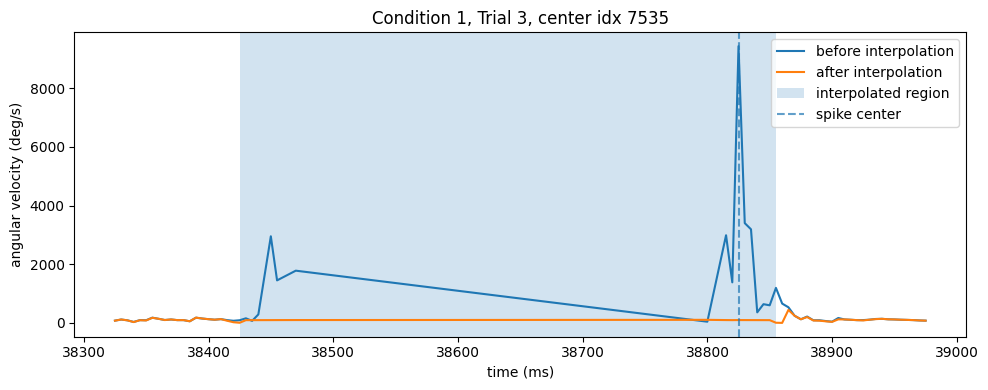

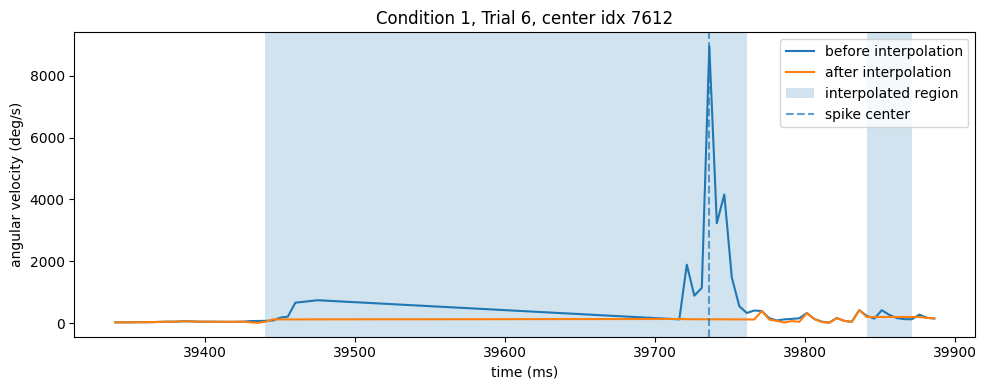

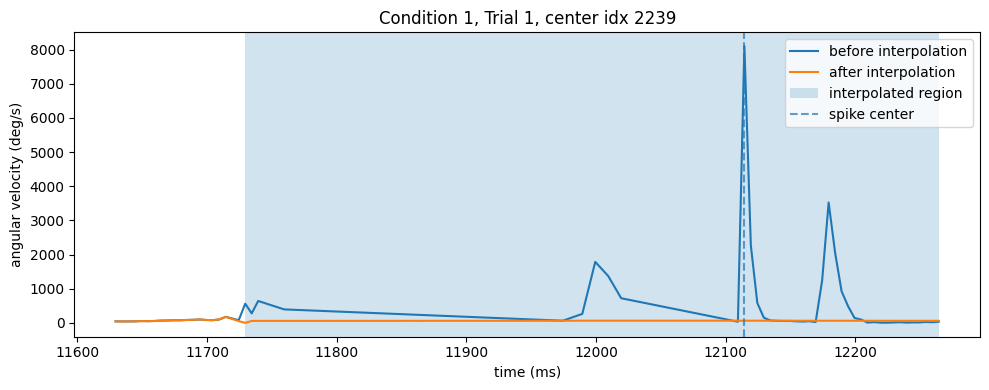

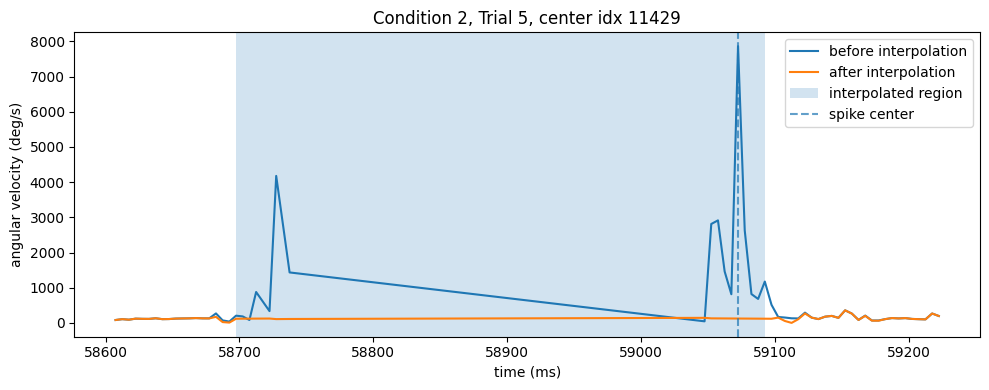

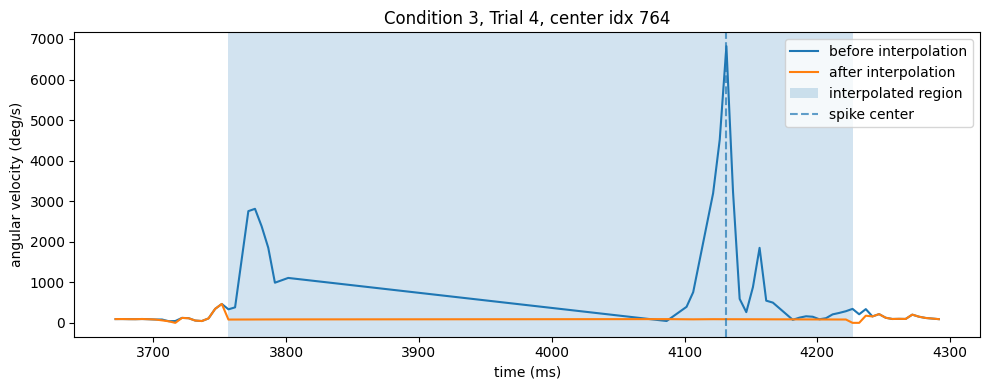

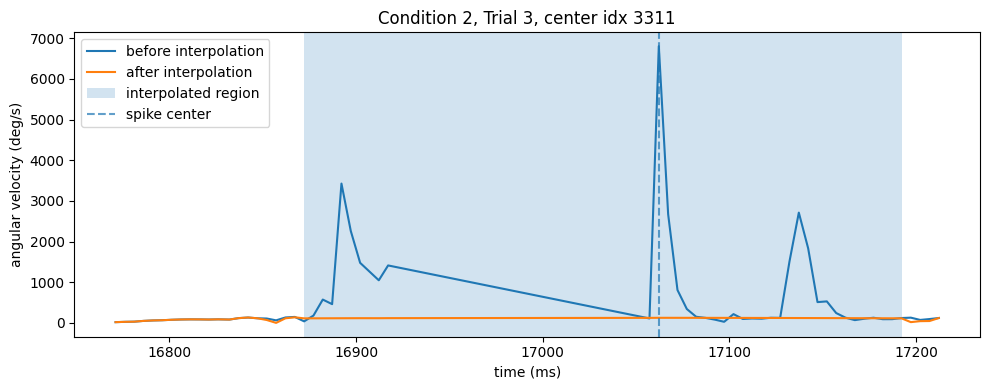

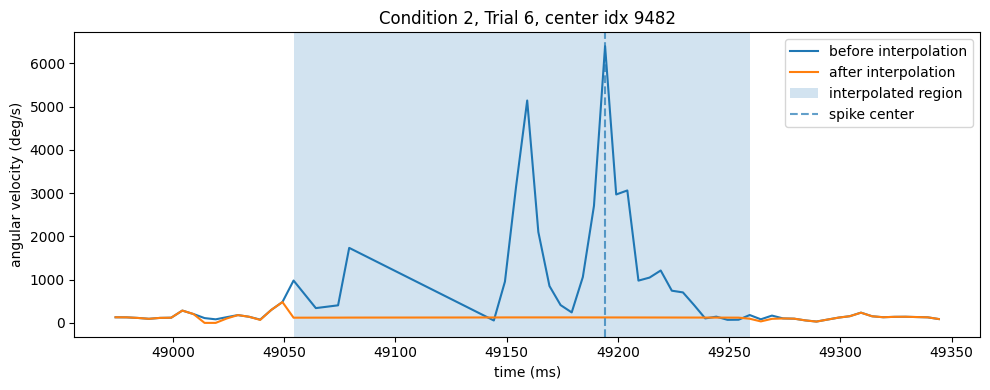

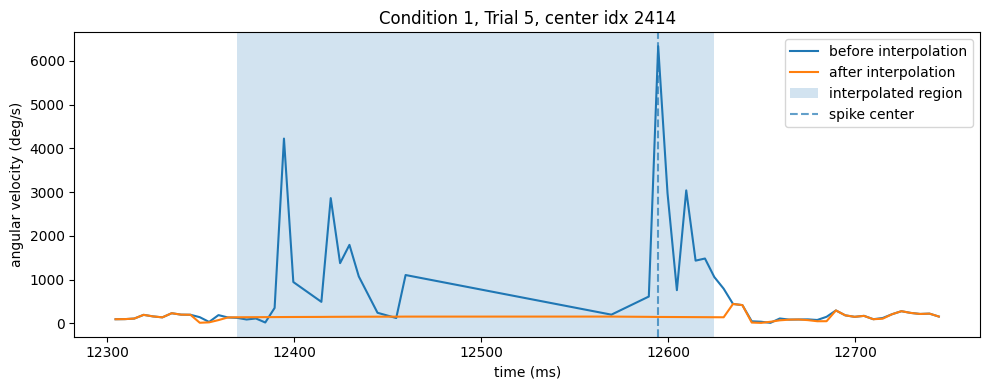

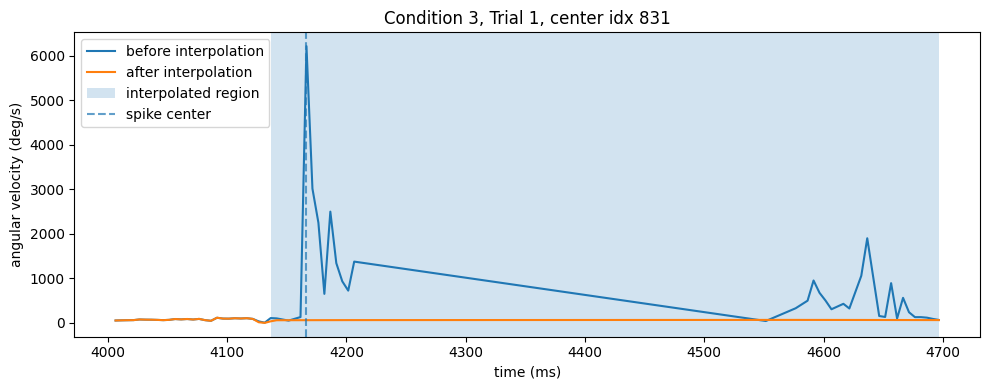

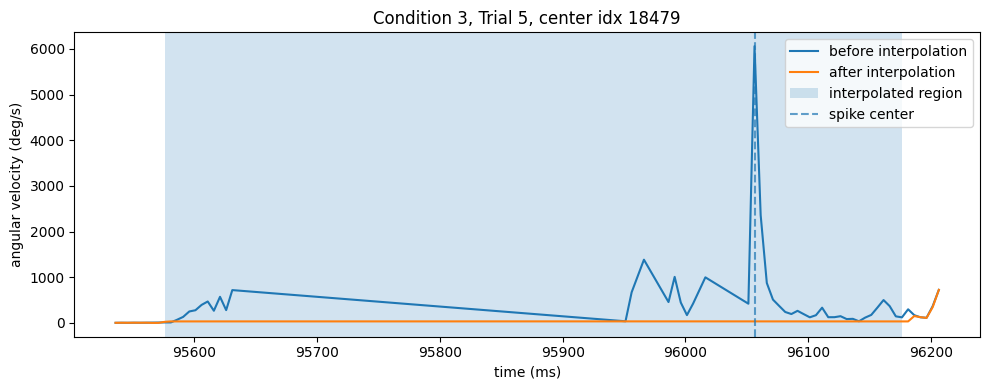

In [46]:
examples_changed = get_spike_examples_from_different_trials(
    df_clean,
    mode="changed",
    delta_threshold=300,
    max_plots=10,
)

plot_multiple_spike_examples(df_clean, examples_changed, pad=30)

### 5 random 30s segments after interpolation look like this

In [41]:
def plot_5_random_segments(df, vel_col="angular_velocity"):
    fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=False)

    trials = df[["condition_number", "trial_number"]].drop_duplicates()

    for ax in axes:
        # pick random trial
        row = trials.sample(1).iloc[0]
        cond = row["condition_number"]
        trial = row["trial_number"]

        sub = (
            df[
                (df["condition_number"] == cond) &
                (df["trial_number"] == trial)
            ]
            .sort_values("gaze_capture_time")
            .reset_index(drop=True)
            .copy()
        )

        sub["time_s"] = sub["gaze_capture_time"] / 1e9

        t_min = sub["time_s"].min()
        t_max = sub["time_s"].max()

        # pick 30s window
        if (t_max - t_min) < 30:
            win = sub.copy()
        else:
            start = np.random.uniform(t_min, t_max - 30)
            end = start + 30
            win = sub[(sub["time_s"] >= start) & (sub["time_s"] <= end)].copy()

        win = win.reset_index(drop=True)

        ax.plot(win["time_s"], win[vel_col], label="angular velocity")

        # highlight each interpolated run separately
        interp_mask = win["is_interpolated"].fillna(False).to_numpy(dtype=bool)
        runs = find_runs(interp_mask)

        for a, b in runs:
            t0 = win["time_s"].iloc[a]
            t1 = win["time_s"].iloc[b]
            ax.axvspan(t0, t1, alpha=0.2)

        ax.set_title(f"Cond {cond}, Trial {trial}")
        ax.set_ylabel("deg/s")
        ax.legend()

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

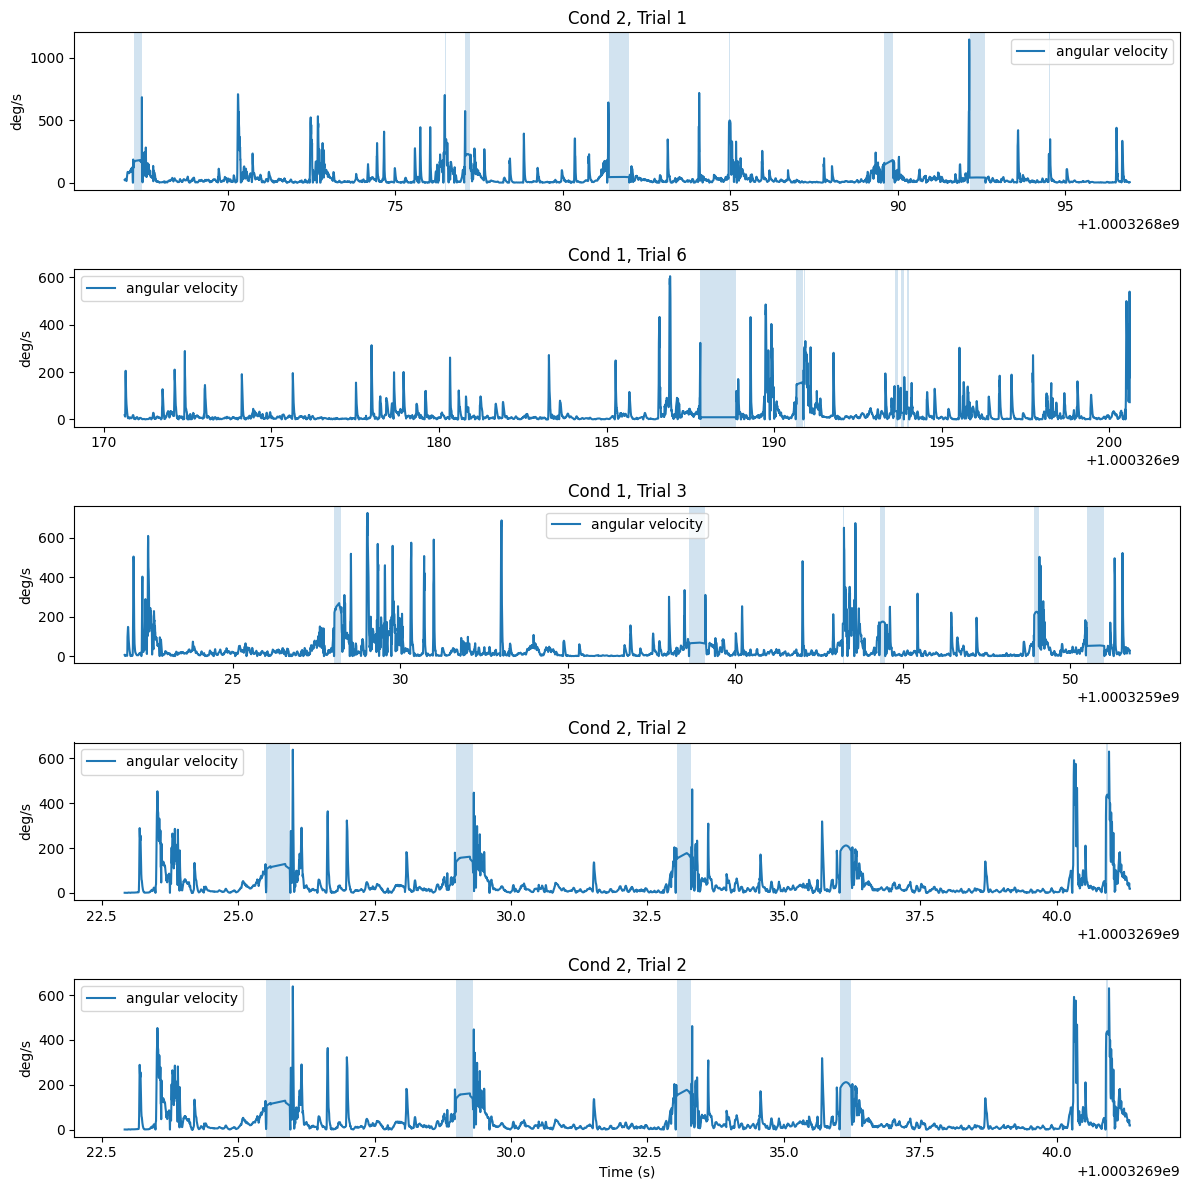

In [42]:
plot_5_random_segments(df_clean)

# Velocity Category

In [38]:
def add_velocity_category(df, vel_col="angular_velocity"):
    """
    Add a simple categorical label based on angular velocity.

    Categories
    ----------
    0–30 deg/s     -> fixation
    30–100 deg/s   -> pursuit
    100–200 deg/s  -> small saccade
    200–400 deg/s  -> medium saccade
    400–700 deg/s  -> large saccade
    >700 deg/s     -> outlier
    """
    df = df.copy()

    df["velocity_category"] = np.select(
        [
            df[vel_col].isna(),
            df[vel_col] < 30,
            df[vel_col] < 100,
            df[vel_col] < 200,
            df[vel_col] < 400,
            df[vel_col] < 700,
            df[vel_col] >= 700
        ],
        [
            "missing",
            "fixation",
            "pursuit",
            "small_saccade",
            "medium_saccade",
            "large_saccade",
            "outlier"
        ],
        default="missing"
    )

    df.loc[df[vel_col].isna(), "velocity_category"] = np.nan

    return df

In [39]:
df_clean = add_velocity_category(df_clean)

In [40]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,gaze_origin_x,gaze_origin_y,gaze_origin_z,left_forward_x,left_forward_y,left_forward_z,left_origin_x,left_origin_y,left_origin_z,left_status,left_pupil_diameter,left_iris_diameter,left_pupil_iris_ratio,left_eye_openness,right_forward_x,right_forward_y,right_forward_z,right_origin_x,right_origin_y,right_origin_z,right_status,right_pupil_diameter,right_iris_diameter,right_pupil_iris_ratio,right_eye_openness,inter_pupillary_distance,hmd_position_x,hmd_position_y,hmd_position_z,hmd_rotation_x,hmd_rotation_y,hmd_rotation_z,hmd_rotation_w,model_name,is_building_model,hit_obj_name,calibration_state,calibration_attempts,left_eye_calibration_quality,right_eye_calibration_quality,condition_number,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,dt,velocity_category
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,0,0,0,0.047548,0.143904,0.988449,-0.033577,0,0,Tracked,4.820606,12.65099,0.381046,1.000000,-0.021272,0.144035,0.989344,0.033577,0,0,Tracked,5.292973,12.58795,0.420479,0.973268,67.200,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000,True,False,False,0.013078,0.144172,0.989466,C1_T1,NaN,NaN,NaN
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,0,0,0,0.047397,0.144022,0.988439,-0.033577,0,0,Tracked,4.815219,12.65099,0.380620,1.000000,-0.021240,0.144152,0.989328,0.033577,0,0,Tracked,5.293125,12.58795,0.420491,0.973297,67.200,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002,True,False,False,0.013059,0.144225,0.989459,C1_T1,0.653459,5.0002,fixation
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,0,0,0,0.047250,0.144130,0.988430,-0.033577,0,0,Tracked,4.812161,12.65099,0.380378,1.000000,-0.021218,0.144258,0.989313,0.033577,0,0,Tracked,5.294265,12.58795,0.420582,0.973327,67.200,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972,True,False,False,0.013039,0.144279,0.989451,C1_T1,0.653878,4.9970,fixation
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,0,0,0,0.047095,0.144188,0.988429,-0.033577,0,0,Tracked,4.808924,12.65099,0.380122,1.000000,-0.021184,0.144316,0.989305,0.033577,0,0,Tracked,5.295160,12.58795,0.420653,0.973373,67.200,0.352501,1.598036,0.020448,0.079321,0.704229,-0.074276,0.701607,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980,True,False,False,0.013003,0.144336,0.989443,C1_T1,0.791661,5.0008,fixation
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,0,0,0,0.046948,0.144232,0.988429,-0.033577,0,0,Tracked,4.806955,12.65099,0.379967,1.000000,-0.021160,0.144359,0.989299,0.033577,0,0,Tracked,5.296308,12.58795,0.420744,0.973384,67.200,0.352550,1.598016,0.020432,0.079370,0.704137,-0.074286,0.701693,C1M3F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997,True,False,False,0.012964,0.144336,0.989444,C1_T1,0.443740,5.0017,fixation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

# Checking fixation stability

In [41]:
def check_fixation_stability(df_clean, dominance_threshold=0.85, min_duration_ms=50):
    """
    Validate fixation labels using hit_obj_name consistency.
    
    A fixation run is considered stable if:
    - Its dominant object covers >= dominance_threshold of non-null samples
    - (Implicitly allows small flickers from edge cases / object boundaries)
    
    Parameters
    ----------
    dominance_threshold : float
        Fraction of samples that must share the same hit_obj_name (e.g. 0.85)
    min_duration_ms : float
        Fixation runs shorter than this are excluded (too short to be meaningful)
    """
    df = df_clean.copy().sort_values(["condition_number", "trial_number", "time_ms"])
    
    # Label contiguous runs of the same velocity_category
    df["run_id"] = (
        (df["velocity_category"] != df["velocity_category"].shift()) |
        (df["condition_number"] != df["condition_number"].shift()) |
        (df["trial_number"] != df["trial_number"].shift())
    ).cumsum()
    
    results = []
    fixation_runs = df[df["velocity_category"] == "fixation"].groupby("run_id")
    
    for run_id, group in fixation_runs:
        duration_ms = group["time_ms"].max() - group["time_ms"].min()
        
        if duration_ms < min_duration_ms:
            continue  # skip very short fixations
        
        named = group["hit_obj_name"].dropna()
        n_named = len(named)
        
        if n_named == 0:
            dominant_obj = None
            dominance = np.nan
            stable = False
        else:
            dominant_obj = named.value_counts().idxmax()
            dominance = named.value_counts().iloc[0] / n_named
            stable = dominance >= dominance_threshold
        
        results.append({
            "run_id": run_id,
            "condition_number": group["condition_number"].iloc[0],
            "trial_number": group["trial_number"].iloc[0],
            "duration_ms": duration_ms,
            "n_samples": len(group),
            "dominant_object": dominant_obj,
            "dominance_ratio": dominance,   # 1.0 = perfectly stable, 0.5 = split between two objects
            "n_unique_objects": group["hit_obj_name"].dropna().nunique(),
            "stable": stable
        })
    
    return pd.DataFrame(results)


# Run it
stability_df = check_fixation_stability(df_clean, dominance_threshold=0.85, min_duration_ms=50)

In [42]:
# 1. Overall stability rate
total = len(stability_df)
stable = stability_df["stable"].sum()
print(f"Stable fixation runs: {stable}/{total} ({100*stable/total:.1f}%)")
print(f"Mean dominance ratio: {stability_df['dominance_ratio'].mean():.3f}")
print()

# 2. Summary table — look at the unstable ones specifically
print("=== Unstable runs ===")
print(stability_df[~stability_df["stable"]].sort_values("dominance_ratio").to_string())

Stable fixation runs: 1151/2245 (51.3%)
Mean dominance ratio: 0.809

=== Unstable runs ===
      run_id  condition_number  trial_number  duration_ms  n_samples            dominant_object  dominance_ratio  n_unique_objects  stable
748     6256                 1             6      90.0120         15    brick_2x4_green_res_027         0.200000                 7   False
201     1888                 1             2    1251.1595        207                 Wall_Front         0.217391                12   False
903     7623                 2             2     145.0183         30         stud_top_1_res_001         0.266667                 5   False
1929   15907                 3             5    1086.1333        218   brick_1x3_green_temp_100         0.275229                 5   False
1918   15866                 3             5     350.0396         71                Model_plate         0.281690                 4   False
1964   16149                 3             5     800.1131        161       

In [43]:
# See which object names appear most in unstable runs — 
unstable = stability_df[~stability_df["stable"]]
print(unstable["dominant_object"].value_counts().head(20))

dominant_object
Lego_Board_10x10             77
resource_desk_base           68
Model_plate                  30
work_desk_base               14
brick_2x4_green_res_038      14
brick_2x4_green_res_027      12
brick_2x4_pink_res_033       11
brick_1x3_yelllow_res_114    10
brick_2x4_yellow_temp_078     9
brick_2x4_pink_res_047        9
brick_2x2_pink_temp_101       9
brick_2x4_yellow_res_098      9
brick_2x2_green_res_110       9
brick_2x4_yellow_res_078      9
brick_2x4_green_res_067       8
brick_2x4_pink_temp_071       8
brick_2x4_pink_res_064        8
brick_2x4_yellow_res_034      8
brick_1x3_yellow_res_076      8
brick_2x4_yellow_res_025      8
Name: count, dtype: int64
